# Wine Fermentation Process Monitoring Dataset

## Data Set: Fermentation data set obtaiend from commercial wine strains in synthetic grape must
Authors/Creators
MINEBOIS, ROMAIN1
Querol, Amparo2

### Descripción
The fermentations were monitored using cumulative CO₂ production, and samples were collected at points defined by ranges of released CO₂, allowing the comparison of equivalent metabolic states across fermentations with different kinetics. One third of the way through the fermentation process, a commercial nutrient supplement was added to simulate real winemaking conditions. This experimental design made it possible to model fermentation dynamics and to identify deviations from normal behavior using unsupervised learning approaches.

This dataset contains raw data from alcoholic fermentations performed with nine commercial Saccharomyces cerevisiae strains under two initial sugar conditions (210 and 250 g/L). Fermentation progress was monitored through weight loss and cumulative CO₂ production.

Samples were collected at different fermentation stages defined by the amount of CO₂ released, rather than by fixed time points, allowing comparison of equivalent metabolic states between fermentations with different speeds. About one third of the way through the fermentation process, a commercial nutrient supplement was added to simulate real winemaking conditions.

Samples were taken for cell count and HPLC analysis at the following accumulated CO2 release values: 

| Stage | CO₂ produced (g/L) | Biological meaning        |
| ----- | ------------------ | ------------------------- |
| T1    | 1–4                | Fermentation start        |
| T2    | 5–15               | Adaptation phase          |
| T3    | 20–35              | Start of active fermentation |
| T4    | 35–50              | Active fermentation       |
| T5    | 50–70              | Mid fermentation          |
| T6    | 70–90              | Late fermentation         |
| T7    | 90–100             | Near completion           |
| T8    | PF                 | End of fermentation       |

**PF (Process Finished):** indicates that fermentation has ended and no significant CO₂ production is observed.

The dataset includes information on yeast growth, sugar consumption, nitrogen availability, and metabolic products, providing a clear overview of fermentation behavior under different conditions.

Specific analyses (not performed at all stages)

Aroma compounds
Aromas were quantified only at T2, T4, T6, T7, and T8, as their formation depends on the physiological state of the yeast and becomes more relevant during the middle and late stages of fermentation.

Amino acids and ammonium
Amino acids and ammonium were measured at selected stages (T0, T1, T2, T3, T5, T7, and T8) because they reflect nitrogen availability for yeast metabolism. Low or rapidly depleted nitrogen levels are known to increase the risk of slow or stuck fermentations.

![Fermentation scheme](fermentation_scheme.jpg)

### Data File Download
https://zenodo.org/records/15260916

## 1. Importando las librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint, uniform

from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    VotingRegressor
)

## 2. Targets and feature sets

In [2]:
# -----------------------------
# Load dataset
# -----------------------------

df = pd.read_excel(
    "Complete_DataSet_Fermentation.xlsx",
    sheet_name="Data"
)
df.columns = df.columns.str.strip()
print("Antiguo Shape: ", df.shape)
df = df[df["Time_name"] != "t5bis"].reset_index(drop=True)
print("Nuevo Shape: ", df.shape)

Antiguo Shape:  (1950, 49)
Nuevo Shape:  (1944, 49)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1944 entries, 0 to 1943
Data columns (total 49 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Strain          1944 non-null   object 
 1   Rep             1944 non-null   object 
 2   Time_name       1944 non-null   object 
 3   Time            1944 non-null   float64
 4   Temperature     1944 non-null   object 
 5   MS              1944 non-null   int64  
 6   Viable          1938 non-null   float64
 7   Dead            1938 non-null   float64
 8   Total           1930 non-null   float64
 9   Glucose         1944 non-null   float64
 10  Fructose        1944 non-null   float64
 11  Glycerol        1944 non-null   float64
 12  Ethanol         1944 non-null   float64
 13  Acetate         1944 non-null   float64
 14  Citrate         1944 non-null   float64
 15  Malate          1944 non-null   float64
 16  Succinate       1944 non-null   float64
 17  Alanine         1644 non-null   f

In [4]:
# -----------------------------
# Basic preprocessing
# -----------------------------
df["run_id"] = (df["Time_name"] == "t0").cumsum()
df["Time_name"] = df["Time_name"].str.replace("t", "", regex=False).astype(int)
df["Time"] = df["Time"] / 24  # hours → days

df["Temperature"] = pd.to_numeric(df["Temperature"], errors="coerce")
df["Sugar"] = df["Glucose"] + df["Fructose"]
df

,Strain,Rep,Time_name,Time,Temperature,MS,Viable,Dead,Total,Glucose,...,IsoamylAcetate,IsoamylAlcohol,EthylHexanoate,EthOctanoate,PhenEthAcetate,PhenEtoh,OctanoicAcid,DecanoicAcid,run_id,Sugar
0,DV10,R1,0,0.000000,12.0,210,848000.0,3960000.0,4808000.0,115.867481,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,229.481997
1,DV10,R1,1,2.229167,12.0,210,1050000.0,4350000.0,5400000.0,109.789286,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,217.733334
2,DV10,R1,2,3.979167,12.0,210,3160000.0,8590000.0,11750000.0,99.909539,...,0.000000,11.831320,0.000000,0.004896,0.000000,2.134086,5.657900,4.691268,1,202.152517
3,DV10,R1,3,6.979167,12.0,210,48000000.0,10800000.0,58800000.0,75.484605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,165.962633
4,DV10,R1,4,7.968750,12.0,210,63500000.0,13200000.0,76700000.0,61.460045,...,0.084834,40.845980,0.135359,0.111390,0.059361,32.421530,17.919683,7.122197,1,141.909706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1939,X5,R3,4,1.958333,NaN,250,67600000.0,8660000.0,76260000.0,72.948292,...,0.355107,114.231294,0.291484,0.094253,0.375164,109.841380,11.459754,11.317683,216,168.095704
1940,X5,R3,5,4.072917,NaN,250,74100000.0,15100000.0,89200000.0,45.688111,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,216,121.020085
1941,X5,R3,6,6.968750,NaN,250,71800000.0,18100000.0,89900000.0,28.415367,...,0.705320,166.982252,0.427612,0.176265,0.534846,94.048809,11.886475,18.573155,216,89.360607
1942,X5,R3,7,10.104167,NaN,250,69100000.0,21900000.0,91000000.0,15.891340,...,0.743386,211.099908,0.456838,0.175041,0.571650,101.950537,11.642267,15.283937,216,62.228919


In [5]:
# -----------------------------
# Encode categorical variables
# -----------------------------
from sklearn.preprocessing import LabelEncoder

df_corr = df.copy()

label_encoders = {}
for col in ["Strain", "Rep"]:
    le = LabelEncoder()
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))
    label_encoders[col] = le

In [6]:
df_corr

,Strain,Rep,Time_name,Time,Temperature,MS,Viable,Dead,Total,Glucose,...,IsoamylAcetate,IsoamylAlcohol,EthylHexanoate,EthOctanoate,PhenEthAcetate,PhenEtoh,OctanoicAcid,DecanoicAcid,run_id,Sugar
0,0,0,0,0.000000,12.0,210,848000.0,3960000.0,4808000.0,115.867481,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,229.481997
1,0,0,1,2.229167,12.0,210,1050000.0,4350000.0,5400000.0,109.789286,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,217.733334
2,0,0,2,3.979167,12.0,210,3160000.0,8590000.0,11750000.0,99.909539,...,0.000000,11.831320,0.000000,0.004896,0.000000,2.134086,5.657900,4.691268,1,202.152517
3,0,0,3,6.979167,12.0,210,48000000.0,10800000.0,58800000.0,75.484605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,165.962633
4,0,0,4,7.968750,12.0,210,63500000.0,13200000.0,76700000.0,61.460045,...,0.084834,40.845980,0.135359,0.111390,0.059361,32.421530,17.919683,7.122197,1,141.909706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1939,8,2,4,1.958333,NaN,250,67600000.0,8660000.0,76260000.0,72.948292,...,0.355107,114.231294,0.291484,0.094253,0.375164,109.841380,11.459754,11.317683,216,168.095704
1940,8,2,5,4.072917,NaN,250,74100000.0,15100000.0,89200000.0,45.688111,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,216,121.020085
1941,8,2,6,6.968750,NaN,250,71800000.0,18100000.0,89900000.0,28.415367,...,0.705320,166.982252,0.427612,0.176265,0.534846,94.048809,11.886475,18.573155,216,89.360607
1942,8,2,7,10.104167,NaN,250,69100000.0,21900000.0,91000000.0,15.891340,...,0.743386,211.099908,0.456838,0.175041,0.571650,101.950537,11.642267,15.283937,216,62.228919


In [7]:
assert df_corr["run_id"].nunique() > 1, "ERROR: run_id mal definido"
assert (df_corr.groupby("run_id").size() > 1).all()
print("✔ run_id correcto y usable para GroupKFold")

✔ run_id correcto y usable para GroupKFold


In [8]:
# Mostrar la correlación entre los atributos del conjunto de datos
corr_matrix = df_corr.corr(method="spearman")

In [9]:
corr_with_time = corr_matrix["Time_name"].sort_values(ascending=False)

# Umbral de correlación
selected_features = corr_with_time[abs(corr_with_time) > 0.8]

# Quitar la propia variable objetivo
selected_features = selected_features.drop("Time_name", errors="ignore")
print("Selected features with correlation to 'estado' > 0.8:\n", selected_features)

Selected features with correlation to 'estado' > 0.8:
 Ethanol       0.974136
Succinate     0.950012
Glycerol      0.935248
Time          0.910197
Acetate       0.870402
EthAcetate    0.830356
Dead          0.801661
Cysteine     -0.804876
Arginine     -0.807016
Threonine    -0.814921
Fructose     -0.924856
Sugar        -0.944556
Glucose      -0.954147
Name: Time_name, dtype: float64


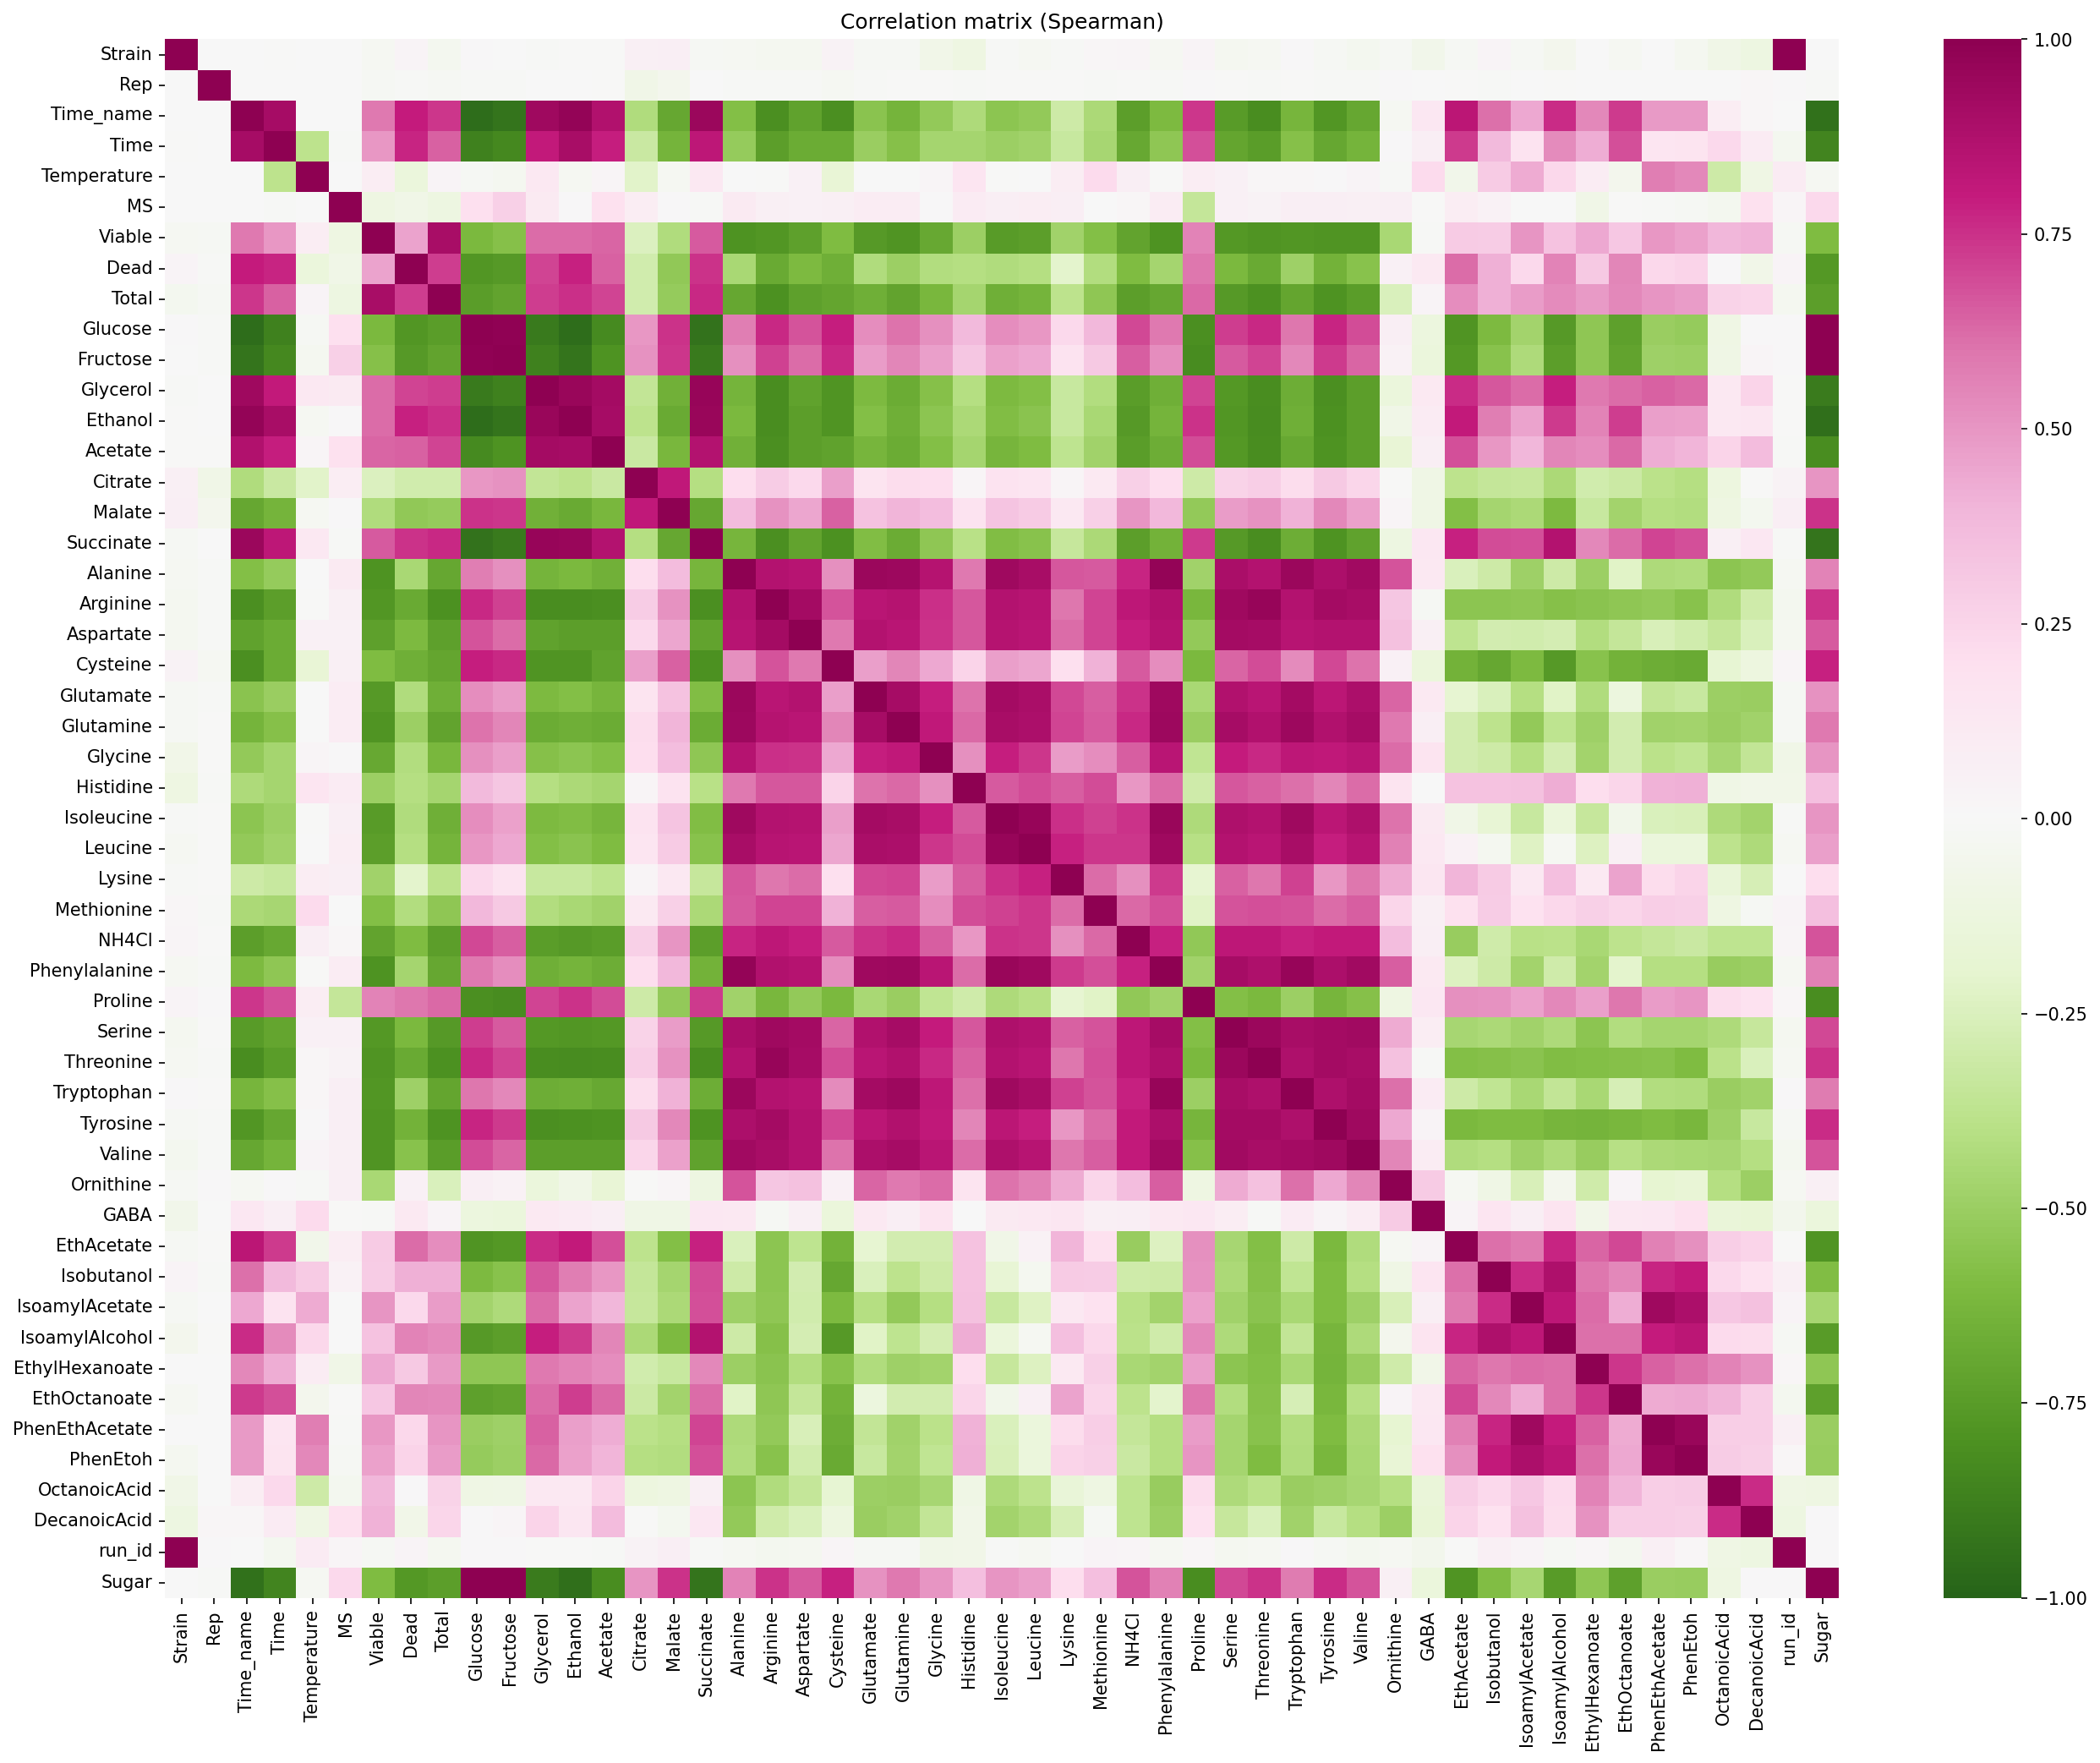

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 14), dpi=150)

sns.heatmap(
    corr_matrix,
    vmin=-1,
    vmax=1,
    cmap="PiYG_r",
    annot=False
)

plt.title("Correlation matrix (Spearman)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
features = ["Ethanol","Succinate","Glycerol","Acetate","EthAcetate","Dead","Cysteine","Arginine","Threonine","Fructose","Sugar","Glucose"]

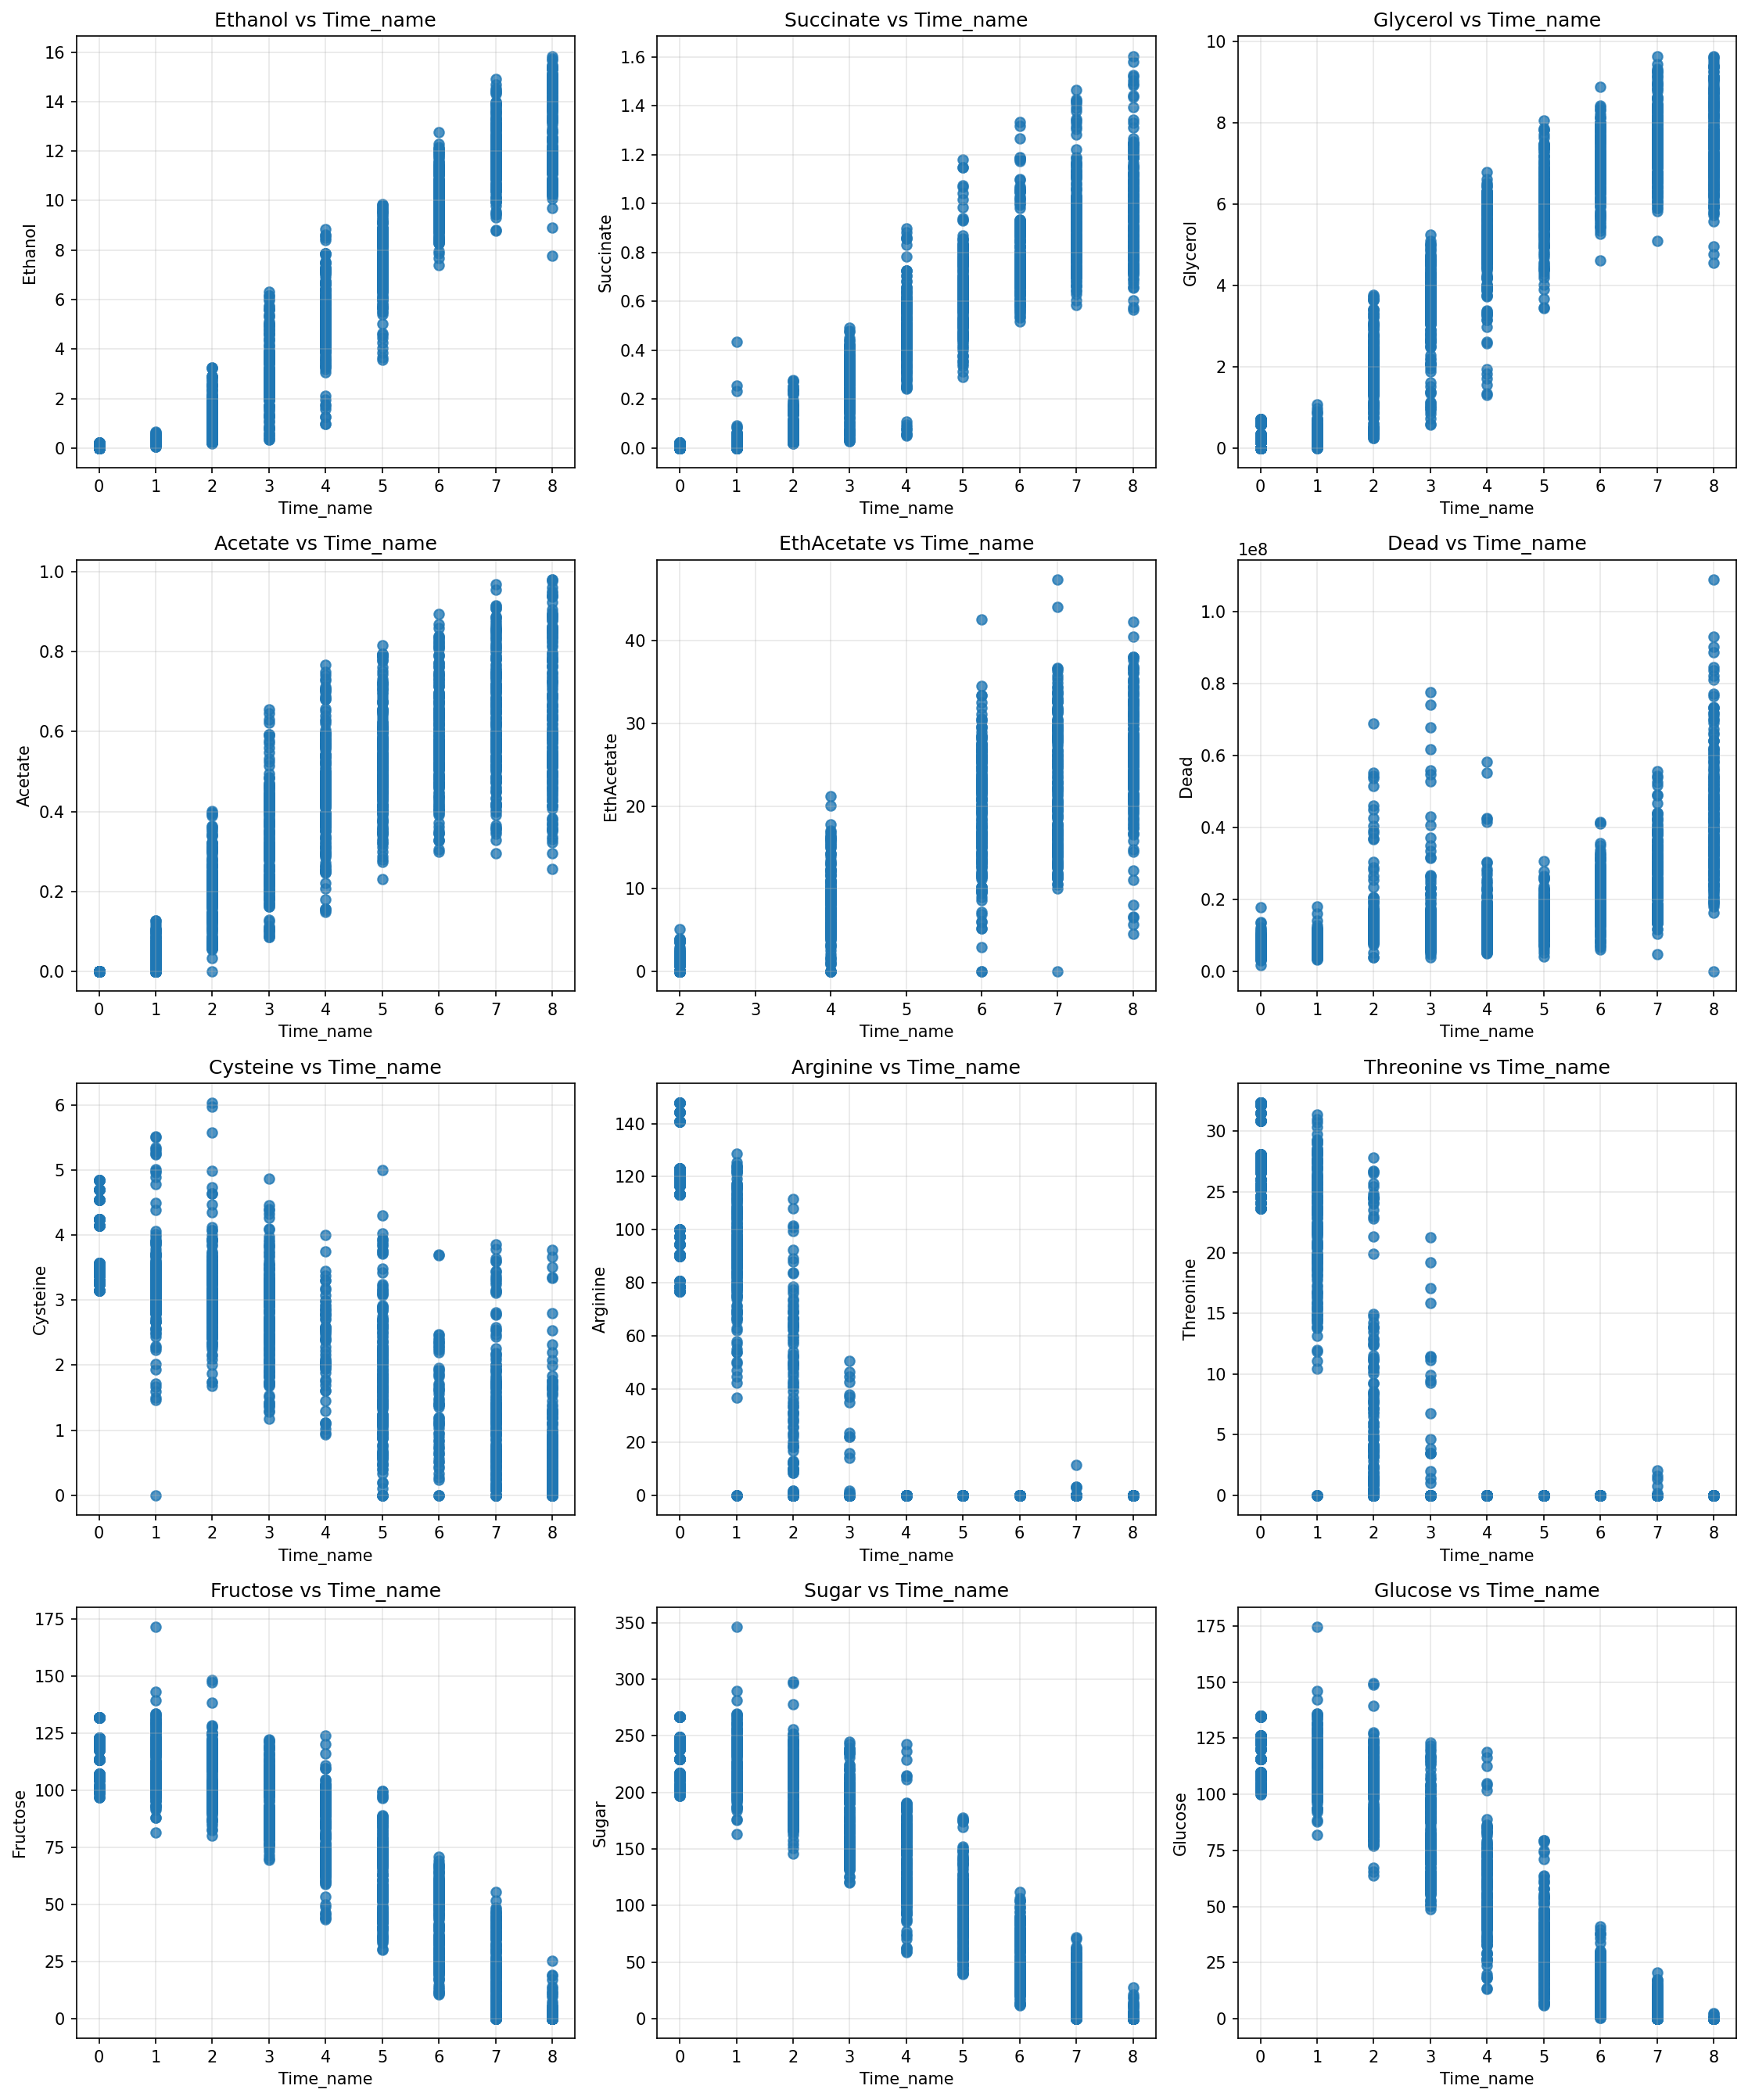

In [12]:
# Crear subplots
fig, axes = plt.subplots(4, 3, figsize=(15, 18), dpi=150)
axes = axes.flatten()

for i, feature in enumerate(features):

    axes[i].scatter(
        df_corr["Time_name"],   # X = tiempo / estado
        df_corr[feature],       # Y = variable
        alpha=0.8
    )

    axes[i].set_xlabel("Time_name")
    axes[i].set_ylabel(feature)
    axes[i].set_title(f"{feature} vs Time_name")
    axes[i].grid(True, alpha=0.3)

# Eliminar subplots vacíos
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

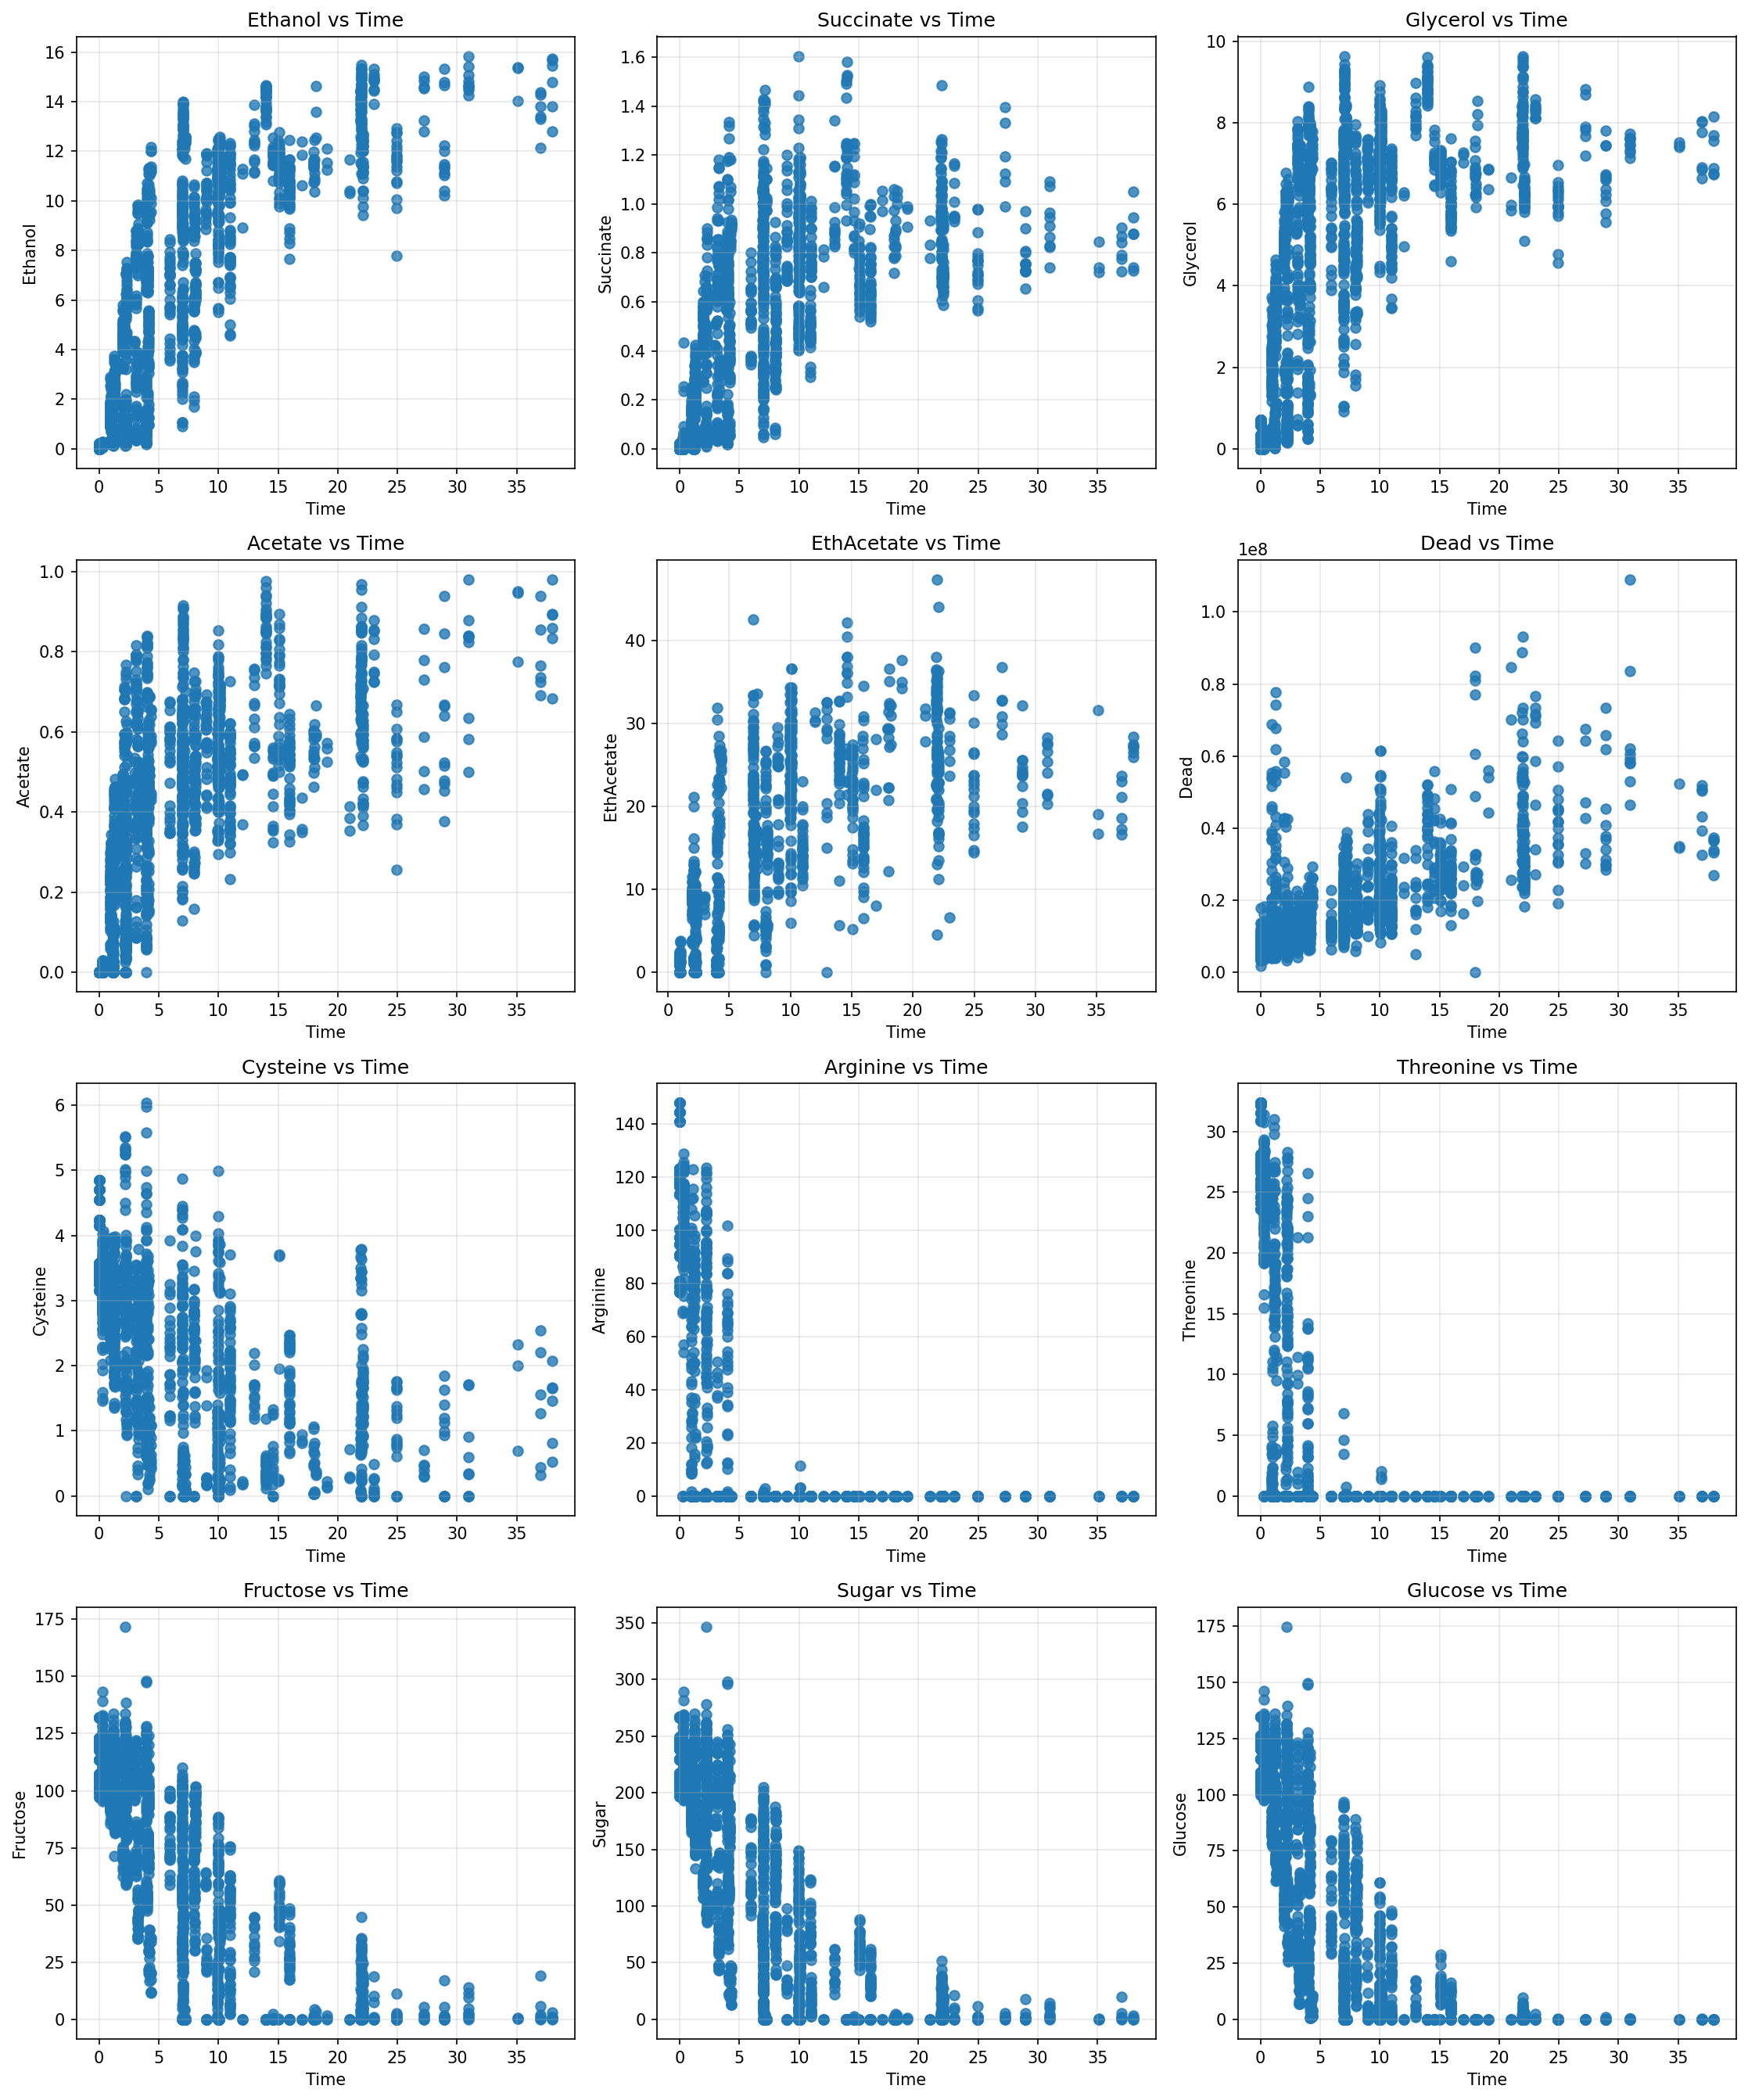

In [13]:
# Crear subplots (4x3)
fig, axes = plt.subplots(4, 3, figsize=(15, 18), dpi=150)
axes = axes.flatten()

for i, feature in enumerate(features):

    axes[i].scatter(
        df_corr["Time"],   # 🔹 X = tiempo continuo
        df_corr[feature],  # 🔹 Y = variable
        alpha=0.8
    )

    axes[i].set_xlabel("Time")
    axes[i].set_ylabel(feature)
    axes[i].set_title(f"{feature} vs Time")
    axes[i].grid(True, alpha=0.3)

# Eliminar subplots vacíos
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [14]:
ferm_data = pd.read_excel('BDD_MANUAL.xlsx')
# ferm_data = ferm_data[relevant_columns]
ferm_data.rename(columns={'dias':'Time', 'sugar': 'Sugar', 'alcohol aprox': 'Ethanol'}, inplace=True)

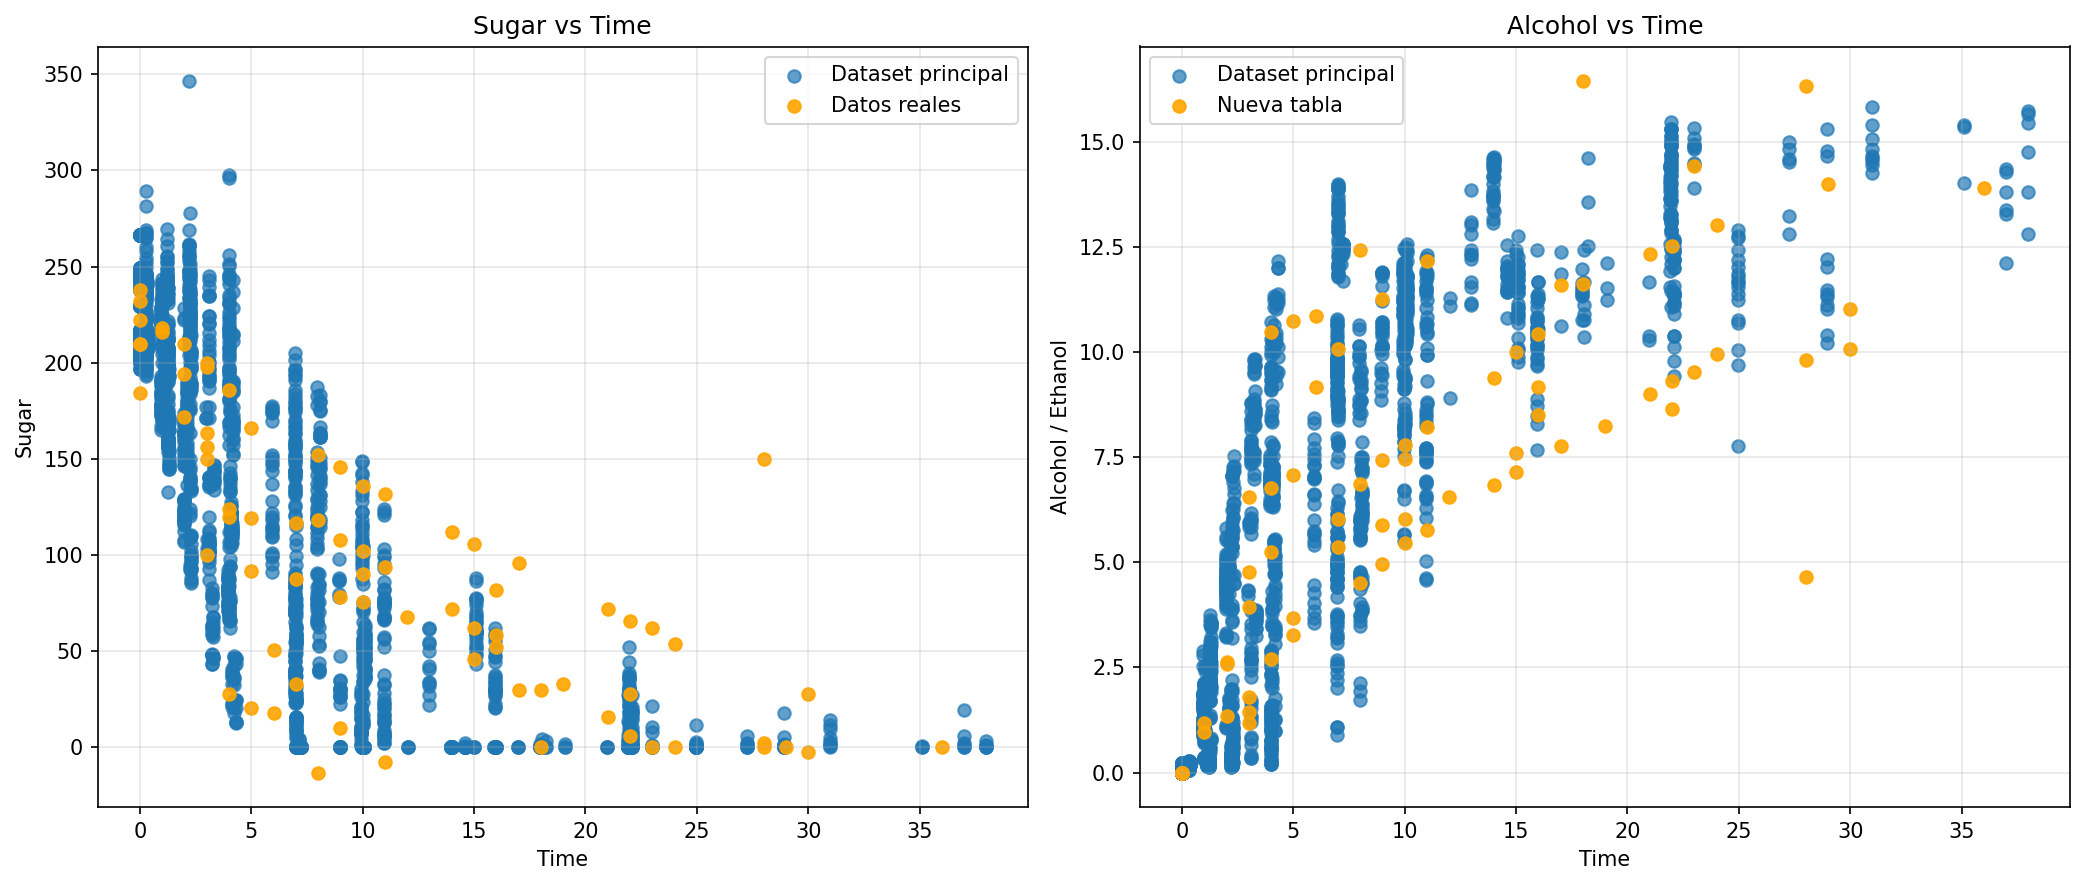

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

# -------- Sugar vs Time --------
axes[0].scatter(
    df_corr["Time"],
    df_corr["Sugar"],
    label="Dataset principal",
    alpha=0.7
)

axes[0].scatter(
    ferm_data["Time"],
    ferm_data["Sugar"],
    color="orange",
    label="Datos reales",
    alpha=0.9
)

axes[0].set_xlabel("Time")
axes[0].set_ylabel("Sugar")
axes[0].set_title("Sugar vs Time")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# -------- Alcohol vs Time --------
axes[1].scatter(
    df_corr["Time"],
    df_corr["Ethanol"],      # ← nombre correcto
    label="Dataset principal",
    alpha=0.7
)

axes[1].scatter(
    ferm_data["Time"],
    ferm_data["Ethanol"],    # ← nombre correcto
    color="orange",
    label="Nueva tabla",
    alpha=0.9
)

axes[1].set_xlabel("Time")
axes[1].set_ylabel("Alcohol / Ethanol")
axes[1].set_title("Alcohol vs Time")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
df_corr["t_remaining"] = 0.0

for run in df_corr["run_id"].unique():
    mask = df_corr["run_id"] == run
    tf = df_corr.loc[mask, "Time"].max()
    df_corr.loc[mask, "t_remaining"] = tf - df_corr.loc[mask, "Time"]
df_corr.head(5)  

,Strain,Rep,Time_name,Time,Temperature,MS,Viable,Dead,Total,Glucose,...,IsoamylAlcohol,EthylHexanoate,EthOctanoate,PhenEthAcetate,PhenEtoh,OctanoicAcid,DecanoicAcid,run_id,Sugar,t_remaining
0,0,0,0,0.000000,12.0,210,848000.0,3960000.0,4808000.0,115.867481,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,229.481997,24.958333
1,0,0,1,2.229167,12.0,210,1050000.0,4350000.0,5400000.0,109.789286,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,217.733334,22.729167
2,0,0,2,3.979167,12.0,210,3160000.0,8590000.0,11750000.0,99.909539,...,11.83132,0.000000,0.004896,0.000000,2.134086,5.657900,4.691268,1,202.152517,20.979167
3,0,0,3,6.979167,12.0,210,48000000.0,10800000.0,58800000.0,75.484605,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,165.962633,17.979167
4,0,0,4,7.968750,12.0,210,63500000.0,13200000.0,76700000.0,61.460045,...,40.84598,0.135359,0.111390,0.059361,32.421530,17.919683,7.122197,1,141.909706,16.989583


In [17]:
# -----------------------------
# Remaining time (RUL) & relative time
# -----------------------------
df_corr["t_remaining"] = 0.0
df_corr["t_rel"] = 0.0

for run in df_corr["run_id"].unique():
    mask = df_corr["run_id"] == run
    t0 = df_corr.loc[mask, "Time"].min()
    tf = df_corr.loc[mask, "Time"].max()
    df_corr.loc[mask, "t_remaining"] = tf - df_corr.loc[mask, "Time"]
    df_corr.loc[mask, "t_rel"] = (df_corr.loc[mask, "Time"] - t0) / (tf - t0)

# Problem Definition and Mathematical Formulation

This study addresses the prediction and monitoring of the alcoholic fermentation process using machine learning models.  
The objective is to model fermentation dynamics in a data-driven yet biologically meaningful way, avoiding excessive dependence on absolute time and instead focusing on process state variables.

The dataset consists of multiple fermentation runs measured at discrete states, including chemical, biological, and process variables.  
Three complementary predictive tasks are defined: alcohol concentration prediction, remaining fermentation time estimation, and fermentation state classification.


## Task 1 — Alcohol Prediction

The first task aims to predict the ethanol concentration during fermentation as a function of substrate availability and its consumption rate.  
Rather than relying on chronological time, the model captures the biochemical relationship between sugar depletion and ethanol production.

### Mathematical formulation
$$
\text{Ethanol} = f\left(\text{Sugar}, \frac{d\,\text{Sugar}}{dt}\right)
$$

where:
- **Sugar** represents the residual sugar concentration,
- $$ (\frac{d\,\text{Sugar}}{dt}) $$ represents the sugar consumption rate,
- **Ethanol** is the predicted alcohol concentration.

---

## Task 2 — Remaining Fermentation Time Prediction (RUL)

The second task focuses on estimating the remaining time until the end of fermentation, formulated as a Remaining Useful Life (RUL) problem.  
This prediction integrates process conditions, substrate availability, metabolic products, and kinetic information.

### Mathematical formulation

$$
t_{\text{remaining}} =
f\left(
\text{Temperature},
\text{Sugar},
\text{Ethanol},
\frac{d\,\text{Sugar}}{dt},
\frac{d\,\text{Ethanol}}{dt}
\right)
$$

where:
- **Temperature** influences fermentation kinetics,
- **Sugar** indicates remaining substrate,
- **Ethanol** reflects fermentation progress and inhibition effects,
- $$ (\frac{d\,\text{Sugar}}{dt}) $$ and $$ (\frac{d\,\text{Ethanol}}{dt})$$ capture dynamic metabolic rates,
- $$ (t_{\text{remaining}}) $$ is the estimated time until fermentation completion.

---

## Task 3 — Fermentation State Classification

The third task consists of classifying the fermentation state into discrete stages based on chemical and process indicators.  
This task supports real-time monitoring and decision-making by identifying the current fermentation phase.

### Mathematical formulation

$$
\text{Time\_name} =
f\left(
\text{Sugar},
\text{Ethanol},
t_{\text{remaining}},
\text{Temperature}
\right)
$$

where:
- **Time_name** denotes the fermentation state,
- **Sugar**, **Ethanol**, and **Temperature** characterize the biochemical and kinetic status,
- $$(t_{\text{remaining}})$$ provides a continuous measure of fermentation progress.

---

## Summary

Together, these three tasks define a hierarchical and process-aware modeling framework:

- Continuous regression models capture fermentation kinetics and completion time.
- A classification model identifies discrete fermentation states.
- Dynamic features enhance early-stage prediction and robustness across fermentation runs.

This formulation ensures both predictive accuracy and interpretability while maintaining consistency with fermentation biology and process engineering principles.

## Feature engineering: DERIVATIVES

In [18]:
# -----------------------------
# Feature engineering: derivatives
# -----------------------------
df_corr = df_corr.sort_values(["run_id", "Time"])

df_corr["dt"] = df_corr.groupby("run_id")["Time"].diff()

df_corr["dSugar_dt"] = (
    df_corr.groupby("run_id")["Sugar"].diff() / df_corr["dt"]
)

df_corr["dEthanol_dt"] = (
    df_corr.groupby("run_id")["Ethanol"].diff() / df_corr["dt"]
)

df_corr.replace([np.inf, -np.inf], np.nan, inplace=True)
df_corr[["dSugar_dt", "dEthanol_dt"]] = (
    df_corr[["dSugar_dt", "dEthanol_dt"]].fillna(0.0)
)

## Targets and feature sets

In [19]:
groups = df_corr["run_id"]

# Targets
y_alcohol = df_corr["Ethanol"]
y_remaining = df_corr["t_remaining"]
y_state = df_corr["Time_name"]

# Feature sets
X_alcohol = df_corr[["Sugar", "dSugar_dt"]]

X_remaining = df_corr[
    ["Temperature", "Sugar", "Ethanol", "dSugar_dt", "dEthanol_dt"]
]

X_state = df_corr[
    ["Sugar", "Ethanol", "t_remaining", "Temperature"]
]

## Train / test split (BY RUN)

In [20]:
gkf = GroupKFold(n_splits=5)

def group_split(X, y, groups):
    for tr, te in gkf.split(X, y, groups):
        return (
            X.iloc[tr], X.iloc[te],
            y.iloc[tr], y.iloc[te],
            groups.iloc[tr], groups.iloc[te]
        )
# -----------------------------
# Train / Test splits
# -----------------------------
# Alcohol
X_alc_tr, X_alc_te, y_alc_tr, y_alc_te, g_alc_tr, g_alc_te = group_split(
    X_alcohol, y_alcohol, groups
)

# Remaining time (RUL)
X_rem_tr, X_rem_te, y_rem_tr, y_rem_te, g_rem_tr, g_rem_te = group_split(
    X_remaining, y_remaining, groups
)

# Fermentation state
X_st_tr, X_st_te, y_st_tr, y_st_te, g_st_tr, g_st_te = group_split(
    X_state, y_state, groups
)

## Models and hyperparameters

In [21]:
regression_models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(),
    "RF": RandomForestRegressor(random_state=42),
    "ET": ExtraTreesRegressor(random_state=42),
    "GB": GradientBoostingRegressor(random_state=42)
}

param_grids = {
    "Ridge": {"model__alpha": np.logspace(-4, 4, 100)},
    "Lasso": {"model__alpha": np.logspace(-5, 1, 100)},
    "SVR": {
        "model__C": uniform(0.1, 100),
        "model__epsilon": uniform(0.01, 0.5),
        "model__gamma": ["scale", "auto"]
    },
    "KNN": {
        "model__n_neighbors": randint(3, 40),
        "model__weights": ["uniform", "distance"]
    },
    "RF": {
        "model__n_estimators": randint(100, 800),
        "model__max_depth": randint(4, 25),
        "model__min_samples_split": randint(2, 15)
    },
    "ET": {
        "model__n_estimators": randint(100, 800),
        "model__max_depth": randint(4, 25)
    },
    "GB": {
        "model__n_estimators": randint(100, 600),
        "model__learning_rate": uniform(0.01, 0.2),
        "model__max_depth": randint(2, 6)
    }
}

## Evaluation function

In [22]:
def evaluate_regression(estimator, Xtr, Xte, ytr, yte, groups_tr=None):
    # PASAR groups SOLO si existe
    if groups_tr is not None:
        estimator.fit(Xtr, ytr, groups=groups_tr)
    else:
        estimator.fit(Xtr, ytr)

    y_pred = estimator.predict(Xte)

    rmse = np.sqrt(mean_squared_error(yte, y_pred))
    r2 = r2_score(yte, y_pred)

    if hasattr(estimator, "best_estimator_"):
        best_model = estimator.best_estimator_
        best_params = estimator.best_params_
    else:
        best_model = estimator
        best_params = None

    return {
        "RMSE": rmse,
        "R2": r2,
        "best_model": best_model,
        "best_params": best_params
    }

## Remaining time (RUL) benchmark

In [23]:
results_remaining = {}

for name, model in regression_models.items():

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
        ("model", model)
    ])

    if name in param_grids:
        search = RandomizedSearchCV(
            pipe,
            param_distributions=param_grids[name],
            n_iter=25,
            scoring="r2",
            cv=GroupKFold(3),
            random_state=42,
            n_jobs=-1
        )

        results_remaining[name] = evaluate_regression(
            search,
            X_rem_tr, X_rem_te,
            y_rem_tr, y_rem_te,
            groups_tr=g_rem_tr
        )

    else:
        results_remaining[name] = evaluate_regression(
            pipe,
            X_rem_tr, X_rem_te,
            y_rem_tr, y_rem_te
        )

In [24]:
results_df = pd.DataFrame({
    name: {
        "RMSE": res["RMSE"],
        "R2": res["R2"],
        "BestParams": res["best_params"]
    }
    for name, res in results_remaining.items()
}).T.sort_values("R2", ascending=False)

print("\n=== Regression Results (Remaining Time) ===")
print(results_df)


=== Regression Results (Remaining Time) ===
            RMSE        R2                                         BestParams
ET      2.061516  0.944785  {'model__max_depth': 14, 'model__n_estimators'...
RF      2.199874  0.937124  {'model__max_depth': 24, 'model__min_samples_s...
GB      2.301843   0.93116  {'model__learning_rate': 0.021616722433639893,...
KNN     2.333754  0.929238  {'model__n_neighbors': 4, 'model__weights': 'd...
SVR     2.451835  0.921897  {'model__C': 97.05846277645585, 'model__epsilo...
Linear  3.972634  0.794957                                                NaN
Ridge   3.972634  0.794957                           {'model__alpha': 0.0001}
Lasso   3.972634  0.794957                            {'model__alpha': 1e-05}


In [25]:
best_model_name = results_df.index[0]
best_scores = results_df.iloc[0]

print("\n🏆 BEST REGRESSION MODEL (RUL)")
print("--------------------------------")
print(f"Model : {best_model_name}")
print(f"R2    : {best_scores['R2']:.4f}")
print(f"RMSE  : {best_scores['RMSE']:.4f}")


🏆 BEST REGRESSION MODEL (RUL)
--------------------------------
Model : ET
R2    : 0.9448
RMSE  : 2.0615


In [26]:
# -----------------------------
# Ensemble model VotingRegressor(RandomForest + ExtraTrees + GradientBoosting)
# -----------------------------
ensemble_remaining = VotingRegressor([
    ("rf", results_remaining["RF"]["best_model"]),
    ("et", results_remaining["ET"]["best_model"]),
    ("gb", results_remaining["GB"]["best_model"])
])

ensemble_remaining.fit(X_rem_tr, y_rem_tr)
pred = ensemble_remaining.predict(X_rem_te)

print("\nEnsemble RMSE:",
      np.sqrt(mean_squared_error(y_rem_te, pred)))


Ensemble RMSE: 2.1514443350854826


El modelo se equivoca, en promedio, ±2.15 días al predecir el tiempo restante de fermentación.

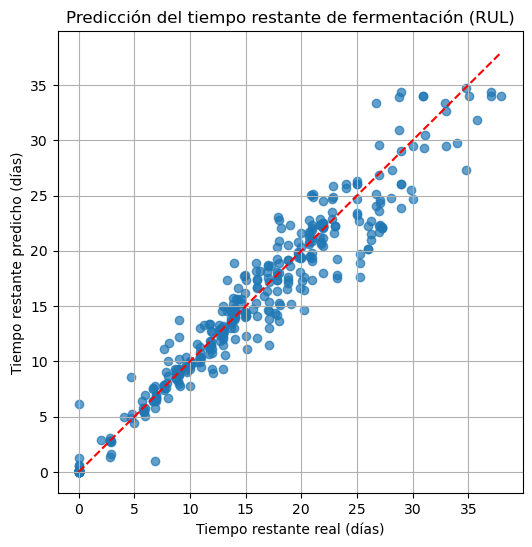

In [27]:
# Predicción con el ensemble de RUL
y_pred_rul = ensemble_remaining.predict(X_rem_te)

plt.figure(figsize=(6,6))
plt.scatter(y_rem_te, y_pred_rul, alpha=0.7)
plt.plot(
    [y_rem_te.min(), y_rem_te.max()],
    [y_rem_te.min(), y_rem_te.max()],
    "r--"
)
plt.xlabel("Tiempo restante real (días)")
plt.ylabel("Tiempo restante predicho (días)")
plt.title("Predicción del tiempo restante de fermentación (RUL)")
plt.grid(True)
plt.show()

In [28]:
# Predicciones individuales (RUL)
y_pred_rf_rul = results_remaining["RF"]["best_model"].predict(X_rem_te)
y_pred_et_rul = results_remaining["ET"]["best_model"].predict(X_rem_te)
y_pred_gb_rul = results_remaining["GB"]["best_model"].predict(X_rem_te)

# Errores
err_rf_rul = y_pred_rf_rul - y_rem_te
err_et_rul = y_pred_et_rul - y_rem_te
err_gb_rul = y_pred_gb_rul - y_rem_te

In [29]:
errors_rul = np.vstack([
    err_rf_rul,
    err_et_rul,
    err_gb_rul
])

cov_rul = np.cov(errors_rul)
print("Covarianza errores T_REMAINING:\n", cov_rul)

Covarianza errores T_REMAINING:
 [[4.75087583 4.29266111 4.70694722]
 [4.29266111 4.18761584 4.35848025]
 [4.70694722 4.35848025 5.16405492]]


In [30]:
import joblib

joblib.dump(ensemble_remaining, "ensemble_rul_fermentation.pkl")

['ensemble_rul_fermentation.pkl']

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

def build_ann(neurons=32, dropout=0.2, lr=0.001, meta=None):
    n_features = meta["n_features_in_"]

    model = Sequential([
        Input(shape=(n_features,)),
        Dense(neurons, activation="relu"),
        Dropout(dropout),
        Dense(neurons // 2, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mse"
    )
    return model

In [32]:
from scikeras.wrappers import KerasRegressor
ann = KerasRegressor(
    model=build_ann,
    verbose=0
)

ann_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("ann", ann)
])

In [44]:
param_dist_ann = {
    "ann__model__neurons": [16, 32, 64, 128],
    "ann__model__dropout": [0.1, 0.2, 0.3],
    "ann__model__lr": [1e-3, 1e-4],
    "ann__epochs": [100, 200, 500],
    "ann__batch_size": [16, 32]
}

In [34]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor="loss",
    patience=15,
    restore_best_weights=True
)

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

ann_search_rem = RandomizedSearchCV(
    ann_pipe,
    param_distributions=param_dist_ann,
    n_iter=15,
    scoring="r2",
    cv=GroupKFold(3),
    random_state=42,
    n_jobs=1
)

ann_search_rem.fit(
    X_rem_tr,
    y_rem_tr,
    groups=g_rem_tr,
    ann__callbacks=[early_stop]
)

y_pred_rem_ann = ann_search_rem.predict(X_rem_te)

rmse_rem_ann = np.sqrt(mean_squared_error(y_rem_te, y_pred_rem_ann))
r2_rem_ann = r2_score(y_rem_te, y_pred_rem_ann)

print("ANN T_remaining RMSE:", rmse_rem_ann)
print("ANN T_remaining R2  :", r2_rem_ann)

ANN T_remaining RMSE: 2.2948416990863887
ANN T_remaining R2  : 0.9315785226320618


# Alcohol

In [36]:
results_alcohol = {}

for name, model in regression_models.items():

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
        ("model", model)
    ])

    if name in param_grids:
        search = RandomizedSearchCV(
            pipe,
            param_distributions=param_grids[name],
            n_iter=25,
            scoring="r2",
            cv=GroupKFold(3),
            random_state=42,
            n_jobs=-1
        )

        results_alcohol[name] = evaluate_regression(
            search,
            X_alc_tr, X_alc_te,
            y_alc_tr, y_alc_te,
            groups_tr=g_alc_tr
        )
    else:
        results_alcohol[name] = evaluate_regression(
            pipe,
            X_alc_tr, X_alc_te,
            y_alc_tr, y_alc_te
        )

In [37]:
results_alcohol_df = pd.DataFrame({
    name: {
        "RMSE": res["RMSE"],
        "R2": res["R2"]
    }
    for name, res in results_alcohol.items()
}).T.sort_values("R2", ascending=False)

print("\n=== Alcohol Prediction Results ===")
print(results_alcohol_df.round(4))


=== Alcohol Prediction Results ===
          RMSE      R2
RF      1.0321  0.9558
ET      1.0517  0.9541
KNN     1.0521  0.9541
GB      1.0598  0.9534
SVR     1.1712  0.9431
Linear  1.3434  0.9252
Ridge   1.3434  0.9252
Lasso   1.3434  0.9252


In [38]:
rmse_alc = results_alcohol_df.iloc[0]["RMSE"]
print("Alcohol RMSE:", rmse_alc)

Alcohol RMSE: 1.0321098127311605


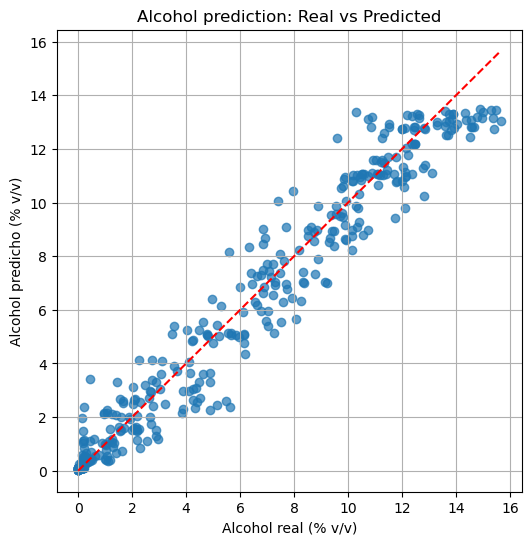

In [39]:
# Elegir el mejor modelo de alcohol
best_alc_name = results_alcohol_df.index[0]
best_alc_model = results_alcohol[best_alc_name]["best_model"]

# Predicción
y_pred_alc = best_alc_model.predict(X_alc_te)

# Gráfico Real vs Predicho
plt.figure(figsize=(6,6))
plt.scatter(y_alc_te, y_pred_alc, alpha=0.7)
plt.plot(
    [y_alc_te.min(), y_alc_te.max()],
    [y_alc_te.min(), y_alc_te.max()],
    "r--"
)
plt.xlabel("Alcohol real (% v/v)")
plt.ylabel("Alcohol predicho (% v/v)")
plt.title("Alcohol prediction: Real vs Predicted")
plt.grid(True)
plt.show()

In [40]:
ensemble_alcohol = VotingRegressor([
    ("rf", results_alcohol["RF"]["best_model"]),
    ("et", results_alcohol["ET"]["best_model"]),
    ("gb", results_alcohol["GB"]["best_model"])
])

ensemble_alcohol.fit(X_alc_tr, y_alc_tr)
y_pred_ens = ensemble_alcohol.predict(X_alc_te)

print(
    "Ensemble Alcohol RMSE:",
    np.sqrt(mean_squared_error(y_alc_te, y_pred_ens))
)

Ensemble Alcohol RMSE: 1.0394934510222662


In [41]:
# Predicciones individuales (alcohol)
y_pred_rf  = results_alcohol["RF"]["best_model"].predict(X_alc_te)
y_pred_et  = results_alcohol["ET"]["best_model"].predict(X_alc_te)
y_pred_gb  = results_alcohol["GB"]["best_model"].predict(X_alc_te)

# Errores
err_rf = y_pred_rf - y_alc_te
err_et = y_pred_et - y_alc_te
err_gb = y_pred_gb - y_alc_te

In [42]:
errors_alcohol = np.vstack([
    err_rf,
    err_et,
    err_gb
])

cov_alcohol = np.cov(errors_alcohol)
print("Covarianza errores ALCOHOL:\n", cov_alcohol)

Covarianza errores ALCOHOL:
 [[1.04096711 1.03228581 1.05497227]
 [1.03228581 1.08168667 1.05726113]
 [1.05497227 1.05726113 1.10139072]]
